<a href="https://colab.research.google.com/github/GFDRR/urban_validation/blob/main/01_building_accuracy_vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Building Footprint Validation — Vector Workflow

This notebook implements a tile-based validation pipeline for city-scale building footprint datasets (e.g., Juba, Kigali, Johannesburg). It compares global / AI-derived building layers against a high-quality reference dataset using a reproducible methodology designed for large geospatial datasets.

The workflow follows a modular structure:

1) Set-up and configurations
2) AOI tiling → the city is divided into fixed-size tiles to support scalable processing
3) Per-tile building matching using greedy 1-to-1 IoU matching
4) Computing accuracy metrics:
* True Positives (TP), False Positives (FP), False Negatives (FN)
* Precision, Recall, F1-score
* Mean IoU for matched buildings
* Boundary-F measure (buffered boundary similarity)
* Relative area error and signed area bias
5) Visualizing outputs
* Per-tile metrics tables
* City-level summaries
* F1 heatmaps and IoU distributions
* Size-dependent error statistics

Created by: Caroline Gevaert - The World Bank

Financed by: The Gates Foundation

Last update: February 5, 2026


In [1]:
import yaml
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import numpy as np

In [ ]:
PROJECT_ROOT = Path(
    # "/content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation" # TODO: adjust to docker environment
    "/content/drive/MyDrive/Gates Foundation/Building Dataset Validation"
)

# === Load config ===
# CONFIG_PATH = PROJECT_ROOT / "configs/ssd-juba.yaml"
CONFIG_PATH = PROJECT_ROOT / "configs/valid_config_ssd_juba_center.yaml"

In [2]:
# TODO: move to a config file (see configs/)
# Project root (folder)
PROJECT_ROOT = Path(
    # "/content/drive/MyDrive/WorldBank/FY26 - DEP/Gates Foundation/Building Dataset Validation" # TODO: adjust to docker environment
    "/content/drive/MyDrive/Gates Foundation/Building Dataset Validation"
)

# === Load config ===
# CONFIG_PATH = PROJECT_ROOT / "configs/ssd-juba.yaml"
CONFIG_PATH = PROJECT_ROOT / "configs/valid_config_ssd_juba_center.yaml"


print("PROJECT_ROOT =", PROJECT_ROOT)
print("CONFIG_PATH =", CONFIG_PATH)

with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

ROOT = (PROJECT_ROOT / cfg["root_dir"]).resolve()
CITY = cfg["city"]

CRS = cfg["crs"]
AOI_PATH = ROOT / cfg["aoi_path"]
REF_PATH = ROOT / cfg["reference_vector"]
CANDIDATES = cfg["candidates"]

MIN_AREA_M2 = cfg.get("min_area_m2", 10)
TILE_SIZE_M = cfg.get("tile_size_m", 1000)  # Default to 1km tiles

# IoU threshold
TAU_OVERLAP = cfg.get("tau_overlap", 0.5)

# Misalignment tolerance (buffer) for vector matching.
# In juba.yaml this is called tau_buffer_m.
TAU_BUFFER_M = cfg.get("tau_buffer_m", cfg.get("tau_misalign_m", 0.0))

# Boundary match threshold (meters). Accept both keys for backward compatibility.
TAU_BOUNDARY_M = cfg.get("tau_boundary_m", cfg.get("tau_boundary", 2.0))

print("City:", CITY)
print("Root:", ROOT)
print("CRS:", CRS)
print("MIN_AREA_M2:", MIN_AREA_M2)
print("TILE_SIZE_M:", TILE_SIZE_M)
print("TAU_OVERLAP:", TAU_OVERLAP)
print("TAU_BUFFER_M:", TAU_BUFFER_M)
print("TAU_BOUNDARY_M:", TAU_BOUNDARY_M)


PROJECT_ROOT = /content/drive/MyDrive/Gates Foundation/Building Dataset Validation
CONFIG_PATH = /content/drive/MyDrive/Gates Foundation/Building Dataset Validation/configs/valid_config_ssd_juba_center.yaml
City: ssd-juba
Root: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation
CRS: EPSG:32636
MIN_AREA_M2: 20
TILE_SIZE_M: 1000
TAU_OVERLAP: 0.5
TAU_BUFFER_M: 2.0
TAU_BOUNDARY_M: 2.0


In [3]:
# TODO: Check to see what can be made modular and moved upstream to vector.py or some other src/ files

FIX_INVALID_GEOMS = True  # set False if you want to skip geometry fixing

def make_valid_if_needed(gdf: gpd.GeoDataFrame, label: str = "") -> gpd.GeoDataFrame:
    """
    Fix invalid geometries (self-intersections, rings, etc.) and drop empty geometries.
    Uses shapely.make_valid when available; falls back to buffer(0).
    """
    gdf = gdf.copy()

    # Drop missing/empty early
    gdf = gdf[~gdf.geometry.isna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    invalid = ~gdf.geometry.is_valid
    n_invalid = int(invalid.sum())

    if n_invalid == 0:
        return gdf

    print(f"[{label}] fixing {n_invalid} invalid geometries...")

    try:
        # Shapely 2.x
        from shapely import make_valid as _make_valid
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].apply(_make_valid)
    except Exception:
        # Fallback (less robust, but often works)
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    # Drop anything that became empty after fixing
    gdf = gdf[~gdf.geometry.isna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    still_invalid = int((~gdf.geometry.is_valid).sum())
    if still_invalid:
        print(f"[{label}] warning: {still_invalid} geometries are still invalid after fixing.")

    return gdf


In [4]:
# def load_buildings(path: Path, crs: str, min_area_m2: float) -> gpd.GeoDataFrame:
#     """Load building footprints, reproject and filter by area."""
#     gdf = gpd.read_file(path)
#     if gdf.crs is None:
#         raise ValueError(f"{path} has no CRS defined.")
#     gdf = gdf.to_crs(crs)

#     if FIX_INVALID_GEOMS:
#         gdf = make_valid_if_needed(gdf, label=path.name)

#     gdf["area_m2"] = gdf.geometry.area
#     gdf = gdf[gdf["area_m2"] >= min_area_m2].copy()
#     gdf.reset_index(drop=True, inplace=True)
#     return gdf
from __future__ import annotations
from typing import Optional, Union

def validate_aoi_geometry(gdf: gpd.GeoDataFrame, label: str = "") -> gpd.GeoDataFrame:
    """
    Fix invalid geometries (self-intersections, rings, etc.) and drop empty geometries.
    Uses shapely.make_valid when available; falls back to buffer(0).
    """
    gdf = gdf.copy()

    # Drop missing/empty early
    gdf = gdf[~gdf.geometry.isna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    invalid = ~gdf.geometry.is_valid
    n_invalid = int(invalid.sum())

    if n_invalid == 0:
        return gdf

    print(f"[{label}] fixing {n_invalid} invalid geometries...")

    try:
        # Shapely 2.x
        from shapely import make_valid as _make_valid
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].apply(_make_valid)
    except Exception:
        # Fallback (less robust, but often works)
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    # Drop anything that became empty after fixing
    gdf = gdf[~gdf.geometry.isna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    still_invalid = int((~gdf.geometry.is_valid).sum())
    if still_invalid:
        print(f"[{label}] warning: {still_invalid} geometries are still invalid after fixing.")

    return gdf


def _read_gdf(path: Union[str, Path]) -> gpd.GeoDataFrame:
    path = Path(path)
    if path.suffix.lower() in [".parquet", ".geoparquet"]:
        return gpd.read_parquet(path)
    return gpd.read_file(path)

def load_buildings(
    path: Union[str, Path],
    *,
    crs_work: str,
    min_area_m2: float,
    fix_invalid_geoms: bool = False,
    compute_area_mode: str = "utm",   # "utm" (robust) | "work_crs" (fast)
    logger=None,
) -> gpd.GeoDataFrame:
    """
    Load building footprints, reproject, compute area in m², and filter.

    Parameters
    ----------
    crs_work : str
        CRS used for spatial ops downstream (tiling, sjoin, etc.)
    compute_area_mode : str
        - "utm": compute area in meters using estimate_utm_crs() (recommended)
        - "work_crs": compute area directly in crs_work (only safe if projected in meters)
    """
    path = Path(path)
    gdf = _read_gdf(path)

    if gdf.crs is None:
        raise ValueError(f"{path} has no CRS defined. (GeoParquet should store CRS; check writer.)")

    # Reproject to working CRS for downstream ops
    gdf = gdf.to_crs(crs_work)

    # Optionally repair invalid geometries
    if fix_invalid_geoms:
        gdf = validate_aoi_geometry(gdf, label=path.name)

    # Compute area in true m²
    try:
        if compute_area_mode == "utm":
            metric_crs = gdf.estimate_utm_crs()
            gdf_metric = gdf.to_crs(metric_crs)
            gdf["area_m2"] = gdf_metric.geometry.area
        elif compute_area_mode == "work_crs":
            # Only correct if crs_work is projected in meters
            gdf["area_m2"] = gdf.geometry.area
        else:
            raise ValueError(f"Unknown compute_area_mode={compute_area_mode!r}. Use 'utm' or 'work_crs'.")
    except Exception as e:
        raise ValueError(
            f"Failed to compute area in meters for {path}. "
            f"Check CRS and geometry validity. Underlying error: {e}"
        )

    gdf = gdf[gdf["area_m2"] >= float(min_area_m2)].copy()
    gdf.reset_index(drop=True, inplace=True)

    if logger:
        logger.info("Loaded buildings | n=%d | min_area_m2=%.2f | path=%s", len(gdf), float(min_area_m2), path)

    return gdf


def load_aoi(path: Path, crs: str) -> gpd.GeoDataFrame:
    """Load AOI polygon(s) for the city."""
    aoi = gpd.read_file(path)
    aoi = aoi.to_crs(crs)
    # dissolve into single polygon if needed
    if len(aoi) > 1:
        aoi = aoi.dissolve().reset_index(drop=True)
    return aoi


def make_tiles(aoi: gpd.GeoDataFrame, tile_size_m: float) -> gpd.GeoDataFrame:
    """Create a regular grid of square tiles covering the AOI."""
    minx, miny, maxx, maxy = aoi.total_bounds
    xs = list(range(int(minx), int(maxx), int(tile_size_m)))
    ys = list(range(int(miny), int(maxy), int(tile_size_m)))

    tiles = []
    for x in xs:
        for y in ys:
            tiles.append(box(x, y, x + tile_size_m, y + tile_size_m))

    tiles_gdf = gpd.GeoDataFrame(geometry=tiles, crs=aoi.crs)
    # Keep only tiles that intersect AOI
    tiles_gdf = tiles_gdf[tiles_gdf.intersects(aoi.geometry.iloc[0])].copy()
    tiles_gdf.reset_index(drop=True, inplace=True)
    tiles_gdf["tile_id"] = tiles_gdf.index.astype(int)
    return tiles_gdf


In [5]:
aoi = load_aoi(AOI_PATH, CRS)
tiles = make_tiles(aoi, TILE_SIZE_M)

# Save to 02_interim so we can reuse the tiling later
tiles_path = ROOT / f"data/02_interim/tiles/{CITY.lower()}_tiles.gpkg"
tiles_path.parent.mkdir(parents=True, exist_ok=True)
tiles.to_file(tiles_path, driver="GPKG")

tiles.head()


,geometry,tile_id
0,"POLYGON ((340785 529418, 340785 530418, 339785...",0
1,"POLYGON ((340785 530418, 340785 531418, 339785...",1
2,"POLYGON ((340785 531418, 340785 532418, 339785...",2
3,"POLYGON ((340785 532418, 340785 533418, 339785...",3
4,"POLYGON ((340785 533418, 340785 534418, 339785...",4


In [6]:
import numpy as np

def _iou_with_buffer(ref_geom, cand_geom, tau_buffer_m: float = 0.0) -> float:
    """IoU with optional buffering to tolerate small georegistration offsets."""
    if tau_buffer_m and tau_buffer_m > 0:
        ref_geom = ref_geom.buffer(tau_buffer_m)
        cand_geom = cand_geom.buffer(tau_buffer_m)

    inter = ref_geom.intersection(cand_geom).area
    if inter <= 0:
        return 0.0
    union = ref_geom.union(cand_geom).area
    if union <= 0:
        return 0.0
    return float(inter / union)


def match_buildings_iou(ref_tile: gpd.GeoDataFrame,
                        cand_tile: gpd.GeoDataFrame,
                        tau_overlap: float,
                        tau_buffer_m: float = 0.0):
    """
    1–1 greedy IoU matching between reference and candidate buildings.

    Rules:
    - Only ref–cand pairs with IoU >= tau_overlap become TP.
    - If a ref building has no candidate with IoU >= tau_overlap -> FN.
    - If a cand building has no ref with IoU >= tau_overlap -> FP.
    - If multiple candidates overlap one ref, the one with highest IoU is TP,
      all others are FP (unmatched cand).
    - If the best IoU for a ref–cand pair is < tau_overlap, the pair contributes
      one FP (cand) and one FN (ref) via the unmatched sets.

    Speed:
    - Uses a spatial join to generate intersecting ref–cand pairs, then computes IoU
      only for those pairs.

    Returns
    -------
    matches_df : DataFrame with one row per TP:
        ['ref_id', 'cand_id', 'iou', 'area_ref', 'area_cand', 'rel_area_error']
    ref_unmatched : set of reference indices (FN)
    cand_unmatched : set of candidate indices (FP)
    """
    empty_cols = ["ref_id", "cand_id", "iou", "area_ref", "area_cand", "rel_area_error"]

    # Edge cases: empty tiles
    if ref_tile.empty and cand_tile.empty:
        return pd.DataFrame(columns=empty_cols), set(), set()
    if ref_tile.empty:
        return pd.DataFrame(columns=empty_cols), set(), set(cand_tile.index)
    if cand_tile.empty:
        return pd.DataFrame(columns=empty_cols), set(ref_tile.index), set()

    # Spatial join to generate candidate pairs (keeps original indices)
    ref_g = ref_tile[["geometry"]].copy()
    cand_g = cand_tile[["geometry"]].copy()

    joined = gpd.sjoin(ref_g, cand_g, how="inner", predicate="intersects")
    if joined.empty:
        return pd.DataFrame(columns=empty_cols), set(ref_tile.index), set(cand_tile.index)

    # joined index = ref index; index_right = cand index
    pairs = joined.reset_index().rename(columns={"index": "ref_id"})[["ref_id", "index_right"]]
    pairs = pairs.rename(columns={"index_right": "cand_id"})

    # Compute IoU per pair
    iou_rows = []
    for ref_id, cand_id in pairs.itertuples(index=False):
        iou = _iou_with_buffer(ref_tile.loc[ref_id].geometry, cand_tile.loc[cand_id].geometry, tau_buffer_m)
        if iou > 0.0:
            iou_rows.append((ref_id, cand_id, iou))

    if not iou_rows:
        return pd.DataFrame(columns=empty_cols), set(ref_tile.index), set(cand_tile.index)

    iou_df = pd.DataFrame(iou_rows, columns=["ref_id", "cand_id", "iou"]).sort_values("iou", ascending=False)

    used_refs = set()
    used_cands = set()
    match_rows = []

    for _, row in iou_df.iterrows():
        ref_id = row["ref_id"]
        cand_id = row["cand_id"]
        iou = float(row["iou"])

        # Because sorted, we can break when IoU goes below threshold
        if iou < tau_overlap:
            break

        if (ref_id in used_refs) or (cand_id in used_cands):
            continue

        used_refs.add(ref_id)
        used_cands.add(cand_id)

        area_ref = float(ref_tile.loc[ref_id, "area_m2"])
        area_cand = float(cand_tile.loc[cand_id, "area_m2"])
        rel_area_error = (area_cand - area_ref) / area_ref if area_ref > 0 else np.nan

        match_rows.append({
            "ref_id": ref_id,
            "cand_id": cand_id,
            "iou": iou,
            "area_ref": area_ref,
            "area_cand": area_cand,
            "rel_area_error": rel_area_error,
        })

    matches_df = pd.DataFrame(match_rows, columns=empty_cols)

    ref_unmatched = set(ref_tile.index) - used_refs
    cand_unmatched = set(cand_tile.index) - used_cands

    return matches_df, ref_unmatched, cand_unmatched


In [7]:
def boundary_f_pair(ref_geom, cand_geom, tau_boundary_m: float) -> float:
    """Boundary F for a single matched pair (length-within-tolerance)."""
    rb = ref_geom.boundary
    cb = cand_geom.boundary
    if rb.length == 0 or cb.length == 0:
        return 0.0

    rb_buf = rb.buffer(tau_boundary_m)
    cb_buf = cb.buffer(tau_boundary_m)

    p = cb.intersection(rb_buf).length / cb.length if cb.length > 0 else 0.0
    r = rb.intersection(cb_buf).length / rb.length if rb.length > 0 else 0.0
    return (2 * p * r / (p + r)) if (p + r) > 0 else 0.0


def compute_boundary_f_for_tile(ref_tile, cand_tile, matches_df, tau_boundary_m):
    """
    Compute boundary F-measure for all TPs in this tile using
    boundary length within buffered boundaries.

    P_b: fraction of candidate boundary within tau_boundary of any reference boundary
    R_b: fraction of reference boundary within tau_boundary of any candidate boundary
    F_b: harmonic mean of P_b and R_b
    """
    if matches_df.empty:
        return 0.0

    ref_ids = matches_df["ref_id"].unique()
    cand_ids = matches_df["cand_id"].unique()

    ref_geoms = ref_tile.loc[ref_ids].geometry
    cand_geoms = cand_tile.loc[cand_ids].geometry

    # Union of boundaries (Shapely 2.x: use union_all instead of unary_union)
    ref_bound = ref_geoms.boundary.union_all()
    cand_bound = cand_geoms.boundary.union_all()

    if ref_bound.length == 0 or cand_bound.length == 0:
        return 0.0

    # Buffers around boundaries
    ref_buffer = ref_bound.buffer(tau_boundary_m)
    cand_buffer = cand_bound.buffer(tau_boundary_m)

    # Precision: fraction of candidate boundary near reference boundary
    cand_correct_geom = cand_bound.intersection(ref_buffer)
    cand_correct_len = cand_correct_geom.length
    P_b = cand_correct_len / cand_bound.length if cand_bound.length > 0 else 0.0

    # Recall: fraction of reference boundary near candidate boundary
    ref_correct_geom = ref_bound.intersection(cand_buffer)
    ref_correct_len = ref_correct_geom.length
    R_b = ref_correct_len / ref_bound.length if ref_bound.length > 0 else 0.0

    if P_b + R_b == 0:
        return 0.0

    return 2 * P_b * R_b / (P_b + R_b)


In [8]:
def _safe_quantile(s: pd.Series, q: float) -> float:
    return float(s.quantile(q)) if len(s) else 0.0


def compute_tile_metrics(ref_tile, cand_tile, tau_overlap, tau_buffer_m, tau_boundary_m, tile_id, dataset_name):
    matches_df, ref_unmatched, cand_unmatched = match_buildings_iou(
        ref_tile, cand_tile, tau_overlap, tau_buffer_m=tau_buffer_m
    )

    # Per-match boundary F (only for TPs)
    if not matches_df.empty:
        bf_vals = []
        for ref_id, cand_id in matches_df[["ref_id", "cand_id"]].itertuples(index=False):
            bf_vals.append(boundary_f_pair(ref_tile.loc[ref_id].geometry, cand_tile.loc[cand_id].geometry, tau_boundary_m))
        matches_df = matches_df.copy()
        matches_df["boundary_f_pair"] = bf_vals

    n_ref = len(ref_tile)
    n_cand = len(cand_tile)
    tp = len(matches_df)
    fn = len(ref_unmatched)
    fp = len(cand_unmatched)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # IoU distribution (TP-only)
    if tp > 0:
        mean_iou = float(matches_df["iou"].mean())
        median_iou = float(matches_df["iou"].median())
        iou_p25 = _safe_quantile(matches_df["iou"], 0.25)
        iou_p75 = _safe_quantile(matches_df["iou"], 0.75)
    else:
        mean_iou = median_iou = iou_p25 = iou_p75 = 0.0

    # Tile-level boundary F (union-based, for continuity with previous runs)
    boundary_f_union = compute_boundary_f_for_tile(ref_tile, cand_tile, matches_df, tau_boundary_m)
    boundary_f_meanpair = float(matches_df["boundary_f_pair"].mean()) if tp > 0 and "boundary_f_pair" in matches_df.columns else 0.0

    mean_rel_area_error = float(matches_df["rel_area_error"].mean()) if tp > 0 else np.nan
    area_ref_sum = float(matches_df["area_ref"].sum()) if tp > 0 else 0.0
    area_cand_sum = float(matches_df["area_cand"].sum()) if tp > 0 else 0.0
    signed_area_bias = ((area_cand_sum - area_ref_sum) / area_ref_sum) if area_ref_sum > 0 else np.nan

    metrics = {
        "city": CITY,
        "dataset": dataset_name,
        "tile_id": tile_id,
        "n_ref": n_ref,
        "n_cand": n_cand,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_iou": mean_iou,
        "median_iou": median_iou,
        "iou_p25": iou_p25,
        "iou_p75": iou_p75,
        "boundary_f_union": boundary_f_union,
        "boundary_f_meanpair": boundary_f_meanpair,
        "mean_rel_area_error": mean_rel_area_error,
        "signed_area_bias": signed_area_bias,
        "tau_overlap": tau_overlap,
        "tau_buffer_m": tau_buffer_m,
        "tau_boundary_m": tau_boundary_m,
    }

    return metrics, matches_df


In [9]:
# Load reference and make spatial index once
ref_all = load_buildings(path = REF_PATH,
                          crs_work = CRS, 
                          min_area_m2= MIN_AREA_M2,
                          fix_invalid_geoms = True)

ref_all_sindex = ref_all.sindex

print("Reference buildings:", len(ref_all))

Reference buildings: 127116


In [10]:
def subset_by_tile(buildings: gpd.GeoDataFrame,
                   sindex,
                   tile_geom):
    """
    Return subset of buildings intersecting a tile geometry.

    - uses spatial index for bbox prefilter
    - preserves original indices (no reset_index)
    """
    possible_idx = list(sindex.intersection(tile_geom.bounds))
    if not possible_idx:
        return buildings.iloc[[]].copy()

    subset = buildings.iloc[possible_idx]
    subset = subset[subset.intersects(tile_geom)].copy()
    # IMPORTANT: do NOT reset index here – we want original indices
    return subset


In [11]:
def fig_name(stem: str, ext: str = "png") -> str:
    # e.g. juba_tile_f1_boxplot_20260203_142530.png
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{CITY.lower()}_{stem}_{ts}.{ext}"

def save_figure(fig, filename: str, dpi: int = 200):
    out_path = figures_dir / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {out_path}")

In [12]:
# Ensure outputs folder
metrics_dir = ROOT / f"outputs/metrics/{CITY.lower()}"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir = ROOT / f"outputs/figures/{CITY.lower()}"
figures_dir.mkdir(parents=True, exist_ok=True)

all_tile_metrics = []
all_match_rows = []

for cand_cfg in CANDIDATES:
    ds_name = cand_cfg["name"]
    cand_path = ROOT / cand_cfg["path"]

    print(f"\n=== Dataset: {ds_name} ===")
    # cand_all = load_buildings(cand_path, CRS, MIN_AREA_M2)
    cand_all = load_buildings(path = cand_path,
                          crs_work = CRS, 
                          min_area_m2= MIN_AREA_M2,
                          fix_invalid_geoms = True)
    cand_all_sindex = cand_all.sindex
    print("Candidate buildings:", len(cand_all))

    ds_tile_metrics = []
    ds_match_rows = []

    for _, tile_row in tiles.iterrows():
        tile_geom = tile_row.geometry
        tile_id = int(tile_row["tile_id"])

        ref_tile = subset_by_tile(ref_all, ref_all_sindex, tile_geom)
        cand_tile = subset_by_tile(cand_all, cand_all_sindex, tile_geom)

        if ref_tile.empty and cand_tile.empty:
            continue

        metrics, matches_df = compute_tile_metrics(
            ref_tile, cand_tile, TAU_OVERLAP, TAU_BUFFER_M, TAU_BOUNDARY_M, tile_id, ds_name
        )
        ds_tile_metrics.append(metrics)

        if not matches_df.empty:
            # Attach context info (city, dataset, tile_id)
            matches_df = matches_df.copy()
            matches_df["city"] = CITY
            matches_df["dataset"] = ds_name
            matches_df["tile_id"] = tile_id
            ds_match_rows.append(matches_df)

    # Save per-dataset tile metrics
    ds_tile_df = pd.DataFrame(ds_tile_metrics)
    tile_out_path = metrics_dir / f"vector_metrics_tiles_{ds_name}.parquet"
    ds_tile_df.to_parquet(tile_out_path, index=False)
    print(f"Saved tile metrics for {ds_name} → {tile_out_path}")

    # Save per-dataset matches
    if ds_match_rows:
        ds_matches_df = pd.concat(ds_match_rows, ignore_index=True)
        match_out_path = metrics_dir / f"vector_matches_{ds_name}.parquet"
        ds_matches_df.to_parquet(match_out_path, index=False)
        print(f"Saved building matches for {ds_name} → {match_out_path}")
    else:
        ds_matches_df = pd.DataFrame(columns=["ref_id", "cand_id", "iou", "area_ref", "area_cand", "rel_area_error", "city", "dataset", "tile_id"])

    all_tile_metrics.append(ds_tile_df)
    all_match_rows.append(ds_matches_df)

# Optional: combined city-wide dataframes
if all_tile_metrics:
    metrics_all = pd.concat(all_tile_metrics, ignore_index=True)
    metrics_all.to_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet", index=False)
    display(metrics_all.head())

if all_match_rows:
    matches_all = pd.concat(all_match_rows, ignore_index=True)
    matches_all.to_parquet(metrics_dir / "vector_matches_all_datasets.parquet", index=False)
    display(matches_all.head())


=== Dataset: overture ===
Candidate buildings: 132050
Saved tile metrics for overture → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/vector_metrics_tiles_overture.parquet
Saved building matches for overture → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/vector_matches_overture.parquet

=== Dataset: gba ===
Candidate buildings: 133876
Saved tile metrics for gba → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/vector_metrics_tiles_gba.parquet
Saved building matches for gba → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/vector_matches_gba.parquet


,city,dataset,tile_id,n_ref,n_cand,tp,fp,fn,precision,recall,...,median_iou,iou_p25,iou_p75,boundary_f_union,boundary_f_meanpair,mean_rel_area_error,signed_area_bias,tau_overlap,tau_buffer_m,tau_boundary_m
0,ssd-juba,overture,0,116,115,78,37,38,0.678261,0.672414,...,0.736041,0.659165,0.935449,0.934829,0.940753,0.139833,0.090262,0.5,2.0,2.0
1,ssd-juba,overture,1,1019,1050,730,320,289,0.695238,0.716389,...,0.689689,0.596859,0.772770,0.872481,0.875515,0.017984,-0.004689,0.5,2.0,2.0
2,ssd-juba,overture,2,1372,1446,1140,306,232,0.788382,0.830904,...,0.829508,0.683862,0.913733,0.904274,0.939826,0.017486,0.008248,0.5,2.0,2.0
3,ssd-juba,overture,3,425,512,329,183,96,0.642578,0.774118,...,0.881248,0.690944,0.991548,0.919045,0.918263,0.105759,0.041966,0.5,2.0,2.0
4,ssd-juba,overture,4,630,803,391,412,239,0.486924,0.620635,...,0.688687,0.607840,0.784599,0.828085,0.837900,0.146809,0.085528,0.5,2.0,2.0


,ref_id,cand_id,iou,area_ref,area_cand,rel_area_error,boundary_f_pair,city,dataset,tile_id
0,75259.0,128967.0,1.0,30.221077,30.221077,0.000000e+00,1.0,ssd-juba,overture,0
1,4823.0,128898.0,1.0,54.337801,54.337801,-1.307640e-16,1.0,ssd-juba,overture,0
2,59437.0,128905.0,1.0,21.583719,21.583719,1.646016e-16,1.0,ssd-juba,overture,0
3,40157.0,128904.0,1.0,44.480639,44.480639,0.000000e+00,1.0,ssd-juba,overture,0
4,113453.0,128847.0,1.0,52.150351,52.150351,0.000000e+00,1.0,ssd-juba,overture,0


In [13]:
# ---------------- Reporting (city-level summaries) ----------------
import pandas as pd

metrics_all_path = metrics_dir / "vector_metrics_tiles_all_datasets.parquet"
matches_all_path = metrics_dir / "vector_matches_all_datasets.parquet"

metrics_all = pd.read_parquet(metrics_all_path) if metrics_all_path.exists() else pd.DataFrame()
matches_all = pd.read_parquet(matches_all_path) if matches_all_path.exists() else pd.DataFrame()

def summarize_city(metrics_df: pd.DataFrame, matches_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for ds, mds in metrics_df.groupby("dataset"):
        # Totals from tiles
        tp = int(mds["tp"].sum())
        fp = int(mds["fp"].sum())
        fn = int(mds["fn"].sum())
        n_ref = int(mds["n_ref"].sum())
        n_cand = int(mds["n_cand"].sum())

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        # Match-based distribution stats (TP-only)
        dsmatches = matches_df[matches_df["dataset"] == ds] if not matches_df.empty else pd.DataFrame()
        if not dsmatches.empty:
            ious = dsmatches["iou"].astype(float)
            bf = dsmatches["boundary_f_pair"].astype(float) if "boundary_f_pair" in dsmatches.columns else pd.Series(dtype=float)
            rel_area = dsmatches["rel_area_error"].astype(float)

            iou_mean = float(ious.mean())
            iou_median = float(ious.median())
            iou_p25 = float(ious.quantile(0.25))
            iou_p75 = float(ious.quantile(0.75))

            bf_mean = float(bf.mean()) if len(bf) else 0.0
            rel_area_mean = float(rel_area.mean())
            rel_area_median = float(rel_area.median())

            area_ref_sum = float(dsmatches["area_ref"].sum())
            area_cand_sum = float(dsmatches["area_cand"].sum())
            signed_area_bias = ((area_cand_sum - area_ref_sum) / area_ref_sum) if area_ref_sum > 0 else float("nan")
        else:
            iou_mean = iou_median = iou_p25 = iou_p75 = 0.0
            bf_mean = 0.0
            rel_area_mean = rel_area_median = float("nan")
            signed_area_bias = float("nan")

        rows.append({
            "city": CITY,
            "dataset": ds,
            "n_tiles": int(mds["tile_id"].nunique()),
            "n_ref_total": n_ref,
            "n_cand_total": n_cand,
            "tp_total": tp,
            "fp_total": fp,
            "fn_total": fn,
            "precision_city": precision,
            "recall_city": recall,
            "f1_city": f1,
            "iou_mean_tp": iou_mean,
            "iou_median_tp": iou_median,
            "iou_p25_tp": iou_p25,
            "iou_p75_tp": iou_p75,
            "boundary_f_meanpair_tp": bf_mean,
            "rel_area_error_mean_tp": rel_area_mean,
            "rel_area_error_median_tp": rel_area_median,
            "signed_area_bias_tp": signed_area_bias,
        })

    return pd.DataFrame(rows)

if not metrics_all.empty:
    city_summary = summarize_city(metrics_all, matches_all)
    summary_path = metrics_dir / "vector_city_summary_all_datasets.parquet"
    city_summary.to_parquet(summary_path, index=False)
    display(city_summary)

    # Also save CSV for quick sharing
    city_summary.to_csv(metrics_dir / "vector_city_summary_all_datasets.csv", index=False)
    print("Saved:", summary_path)


,city,dataset,n_tiles,n_ref_total,n_cand_total,tp_total,fp_total,fn_total,precision_city,recall_city,f1_city,iou_mean_tp,iou_median_tp,iou_p25_tp,iou_p75_tp,boundary_f_meanpair_tp,rel_area_error_mean_tp,rel_area_error_median_tp,signed_area_bias_tp
0,ssd-juba,gba,73,129490,136277,75108,61169,54382,0.551142,0.580029,0.565217,0.699071,0.698445,0.610044,0.784327,0.871470,0.080781,0.046119,0.037270
1,ssd-juba,overture,73,129490,134485,93821,40664,35669,0.697632,0.724542,0.710832,0.820940,0.821262,0.675335,1.000000,0.925052,0.043194,0.000000,0.020823


Saved: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/vector_city_summary_all_datasets.parquet


Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_tile_f1_boxplot_20260305_093552.png


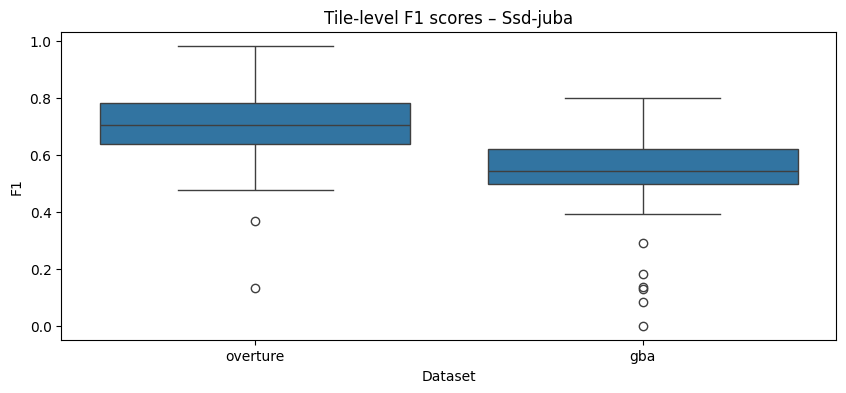

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")

fig, ax = plt.subplots(figsize=(10, 4))  # optional but recommended for consistency
sns.boxplot(data=metrics_all, x="dataset", y="f1", ax=ax)

ax.set_title(f"Tile-level F1 scores – {CITY.capitalize()}")
ax.set_xlabel("Dataset")
ax.set_ylabel("F1")

save_figure(fig, fig_name("tile_f1_boxplot"))
plt.show()


Datasets found: ['overture' 'gba']
Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – Tile-level F1 for overture_20260305_093553.png


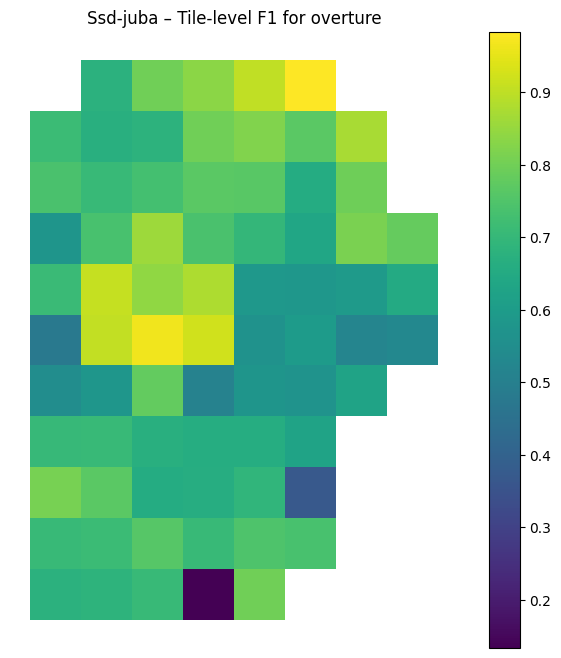

Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – Tile-level F1 for gba_20260305_093553.png


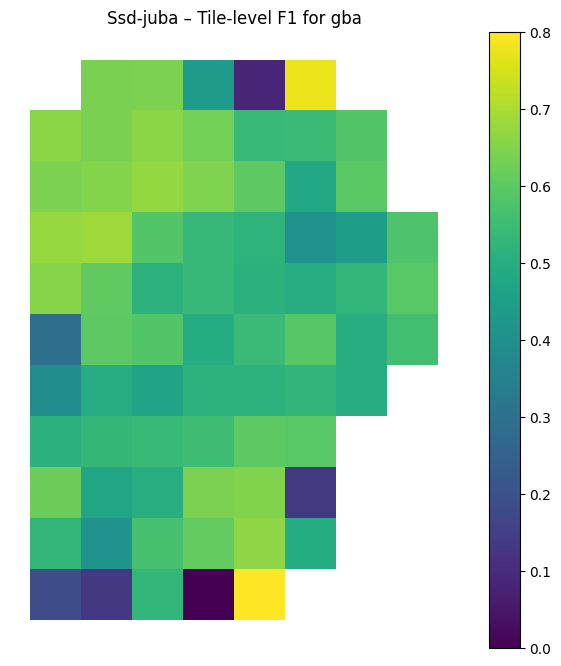

In [15]:
import matplotlib.pyplot as plt

# Load tiles and metrics
tiles_path = ROOT / f"data/02_interim/tiles/{CITY.lower()}_tiles.gpkg"
tiles = gpd.read_file(tiles_path)

metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")

# Get the list of datasets present in the metrics table
datasets = metrics_all["dataset"].unique()
print("Datasets found:", datasets)

for ds_to_plot in datasets:
    # Filter metrics for this dataset
    metrics_ds = metrics_all[metrics_all["dataset"] == ds_to_plot]

    if metrics_ds.empty:
        print(f"Skipping {ds_to_plot}: no metrics available.")
        continue

    # Join F1 to tiles
    tiles_metrics = tiles.merge(
        metrics_ds[["tile_id", "f1"]],
        on="tile_id",
        how="left"
    )

    # Plot tile-level F1 for this dataset
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    tiles_metrics.plot(
        column="f1",
        ax=ax,
        legend=True,
        cmap="viridis",
        edgecolor="none"
    )
    ax.set_title(f"{CITY.capitalize()} – Tile-level F1 for {ds_to_plot}")
    ax.set_axis_off()

    save_figure(fig, fig_name(f"{CITY.capitalize()} – Tile-level F1 for {ds_to_plot}"))

    plt.show()


Datasets found: ['overture' 'gba'] 

=== Ssd-juba — overture ===
TP: 93,821  FP: 40,664  FN: 35,669
TP-only IoU mean: 0.821  (n=93,821)
All buildings (TP + FP + FN→0) IoU mean: 0.453  (n=170,154)


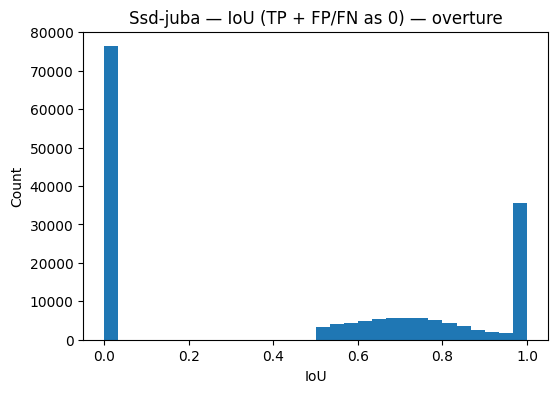


=== Ssd-juba — gba ===
TP: 75,108  FP: 61,169  FN: 54,382
TP-only IoU mean: 0.699  (n=75,108)
All buildings (TP + FP + FN→0) IoU mean: 0.275  (n=190,659)


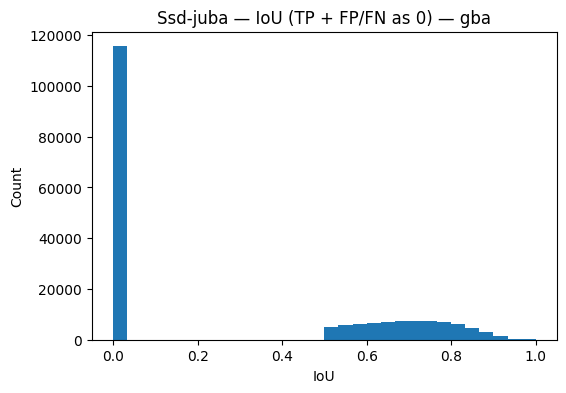

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load metrics + matches
metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")
matches_all = pd.read_parquet(metrics_dir / "vector_matches_all_datasets.parquet")

datasets = metrics_all["dataset"].unique()
print("Datasets found:", datasets, "\n")

for ds_to_plot in datasets:
    print(f"=== {CITY.capitalize()} — {ds_to_plot} ===")

    # --- Tile-level TP / FP / FN totals ---
    m_ds = metrics_all[metrics_all["dataset"] == ds_to_plot]

    tp = m_ds["tp"].sum()
    fp = m_ds["fp"].sum()
    fn = m_ds["fn"].sum()

    print(f"TP: {tp:,}  FP: {fp:,}  FN: {fn:,}")

    # --- IoU for TP matches only ---
    ious_tp = matches_all[matches_all["dataset"] == ds_to_plot]["iou"].dropna()

    # --- Add zeros for FP + FN to approximate 'all buildings' view ---
    num_zeros = fp + fn
    ious_all = pd.concat(
        [ious_tp, pd.Series(np.zeros(num_zeros))],
        ignore_index=True
    )

    print(f"TP-only IoU mean: {ious_tp.mean():.3f}  (n={len(ious_tp):,})")
    print(f"All buildings (TP + FP + FN→0) IoU mean: {ious_all.mean():.3f}  (n={len(ious_all):,})")

    # --- Plot histogram ---
    plt.figure(figsize=(6, 4))
    plt.hist(ious_all, bins=30)
    plt.title(f"{CITY.capitalize()} — IoU (TP + FP/FN as 0) — {ds_to_plot}")
    plt.xlabel("IoU")
    plt.ylabel("Count")
    plt.show()

    print()  # spacing between datasets


Datasets found: ['overture' 'gba']

=== Ssd-juba — overture ===


,size_bin,mean_iou,median_iou,median_rel_area_error,count
0,<25,0.833421,0.872320,0.0,10701
1,25–50,0.820942,0.821399,0.0,40069
2,50–100,0.815166,0.809629,0.0,25019
3,100–500,0.820070,0.818631,0.0,17080
4,500–1000,0.838778,0.854852,0.0,756
5,>1000,0.883308,0.898354,0.0,196


Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – IoU vs building size – overture_20260305_093554.png


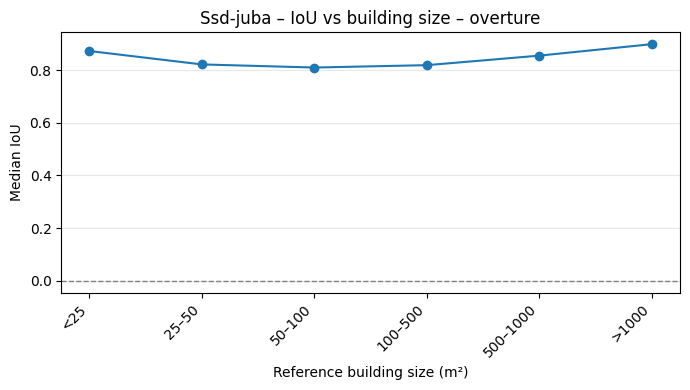

Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – Relative area error vs building size – overture_20260305_093554.png


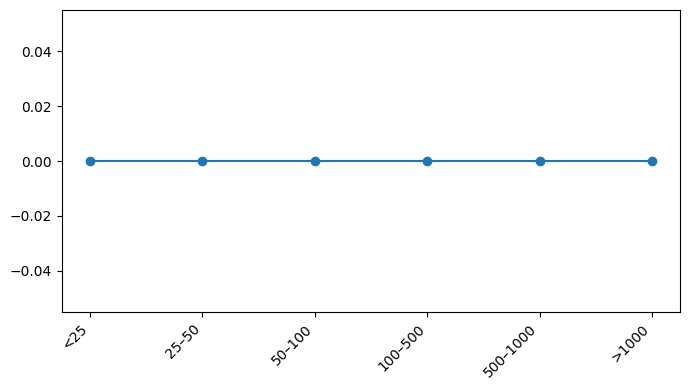


=== Ssd-juba — gba ===


,size_bin,mean_iou,median_iou,median_rel_area_error,count
0,<25,0.675376,0.668696,0.182228,6446
1,25–50,0.687374,0.684312,0.063184,31675
2,50–100,0.698866,0.698708,0.010133,21574
3,100–500,0.732169,0.741958,0.026849,14710
4,500–1000,0.752582,0.774091,-0.007045,578
5,>1000,0.777742,0.811032,-0.002990,125


Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – IoU vs building size – gba_20260305_093554.png


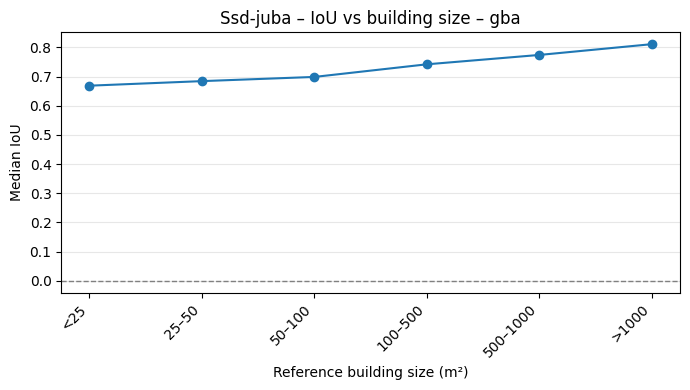

Saved figure: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/figures/ssd-juba/ssd-juba_Ssd-juba – Relative area error vs building size – gba_20260305_093555.png


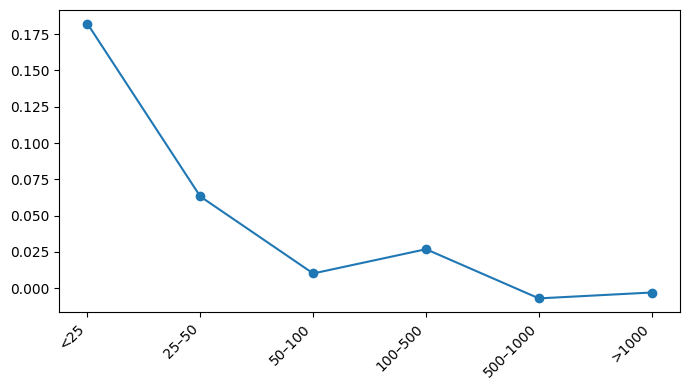

In [17]:
# ---------------- USER SETTINGS ----------------
USE_EXPLICIT_BINS = True   # set to False to use quantile bins

# Explicit bins (used if USE_EXPLICIT_BINS=True)
size_bins = [0, 25, 50, 100, 500, 1000, np.inf] # 5 hist-equalize results in 25, 33, 46, 74, 8584 for Juba
size_bin_labels = [
    "<25",
    "25–50",
    "50–100",
    "100–500",
    "500–1000",
    ">1000"
]

# Quantile bins (used if USE_EXPLICIT_BINS=False)
n_bins = 5
# ------------------------------------------------

matches_all = pd.read_parquet(metrics_dir / "vector_matches_all_datasets.parquet")

datasets = matches_all["dataset"].unique()
print("Datasets found:", datasets)

for ds in datasets:
    print(f"\n=== {CITY.capitalize()} — {ds} ===")

    m_ds = matches_all[matches_all["dataset"] == ds].copy()

    if m_ds.empty:
        print("No matched buildings for this dataset.")
        continue

    # ---- Define building size bins ----
    if USE_EXPLICIT_BINS:
        m_ds["size_bin"] = pd.cut(
            m_ds["area_ref"],
            bins=size_bins,
            labels=size_bin_labels,
            include_lowest=True
        )
    else:
        m_ds["size_bin"] = pd.qcut(
            m_ds["area_ref"],
            q=n_bins,
            duplicates="drop"
        )

    # ---- Aggregate statistics per size bin ----
    size_stats = (
        m_ds
        .groupby("size_bin", observed=True)
        .agg(
            mean_iou=("iou", "mean"),
            median_iou=("iou", "median"),
            median_rel_area_error=("rel_area_error", "median"),
            count=("iou", "size")
        )
        .reset_index()
    )

    display(size_stats)

    # ---- Plot: IoU vs building size ----
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        size_stats["size_bin"].astype(str),
        size_stats["median_iou"],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    for label in ax.get_xticklabels():
      label.set_ha("right")
    ax.set_ylabel("Median IoU")
    ax.set_xlabel("Reference building size (m²)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{CITY.capitalize()} – IoU vs building size – {ds}")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    save_figure(fig, fig_name(f"{CITY.capitalize()} – IoU vs building size – {ds}"))

    plt.show()
    plt.close(fig)

    # ---- Plot: Relative area error vs building size ----
    fig = plt.figure(figsize=(7, 4))
    plt.plot(
        size_stats["size_bin"].astype(str),
        size_stats["median_rel_area_error"],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    ax.set_ylabel("Median relative area error")
    ax.set_xlabel("Reference building size (m²)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{CITY.capitalize()} – Relative area error vs building size – {ds}")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    save_figure(fig, fig_name(f"{CITY.capitalize()} – Relative area error vs building size – {ds}"))

    plt.show()